In [1]:
import sys
sys.path.append('/raid1/mmenessini/git/hcipy/') 


from hcipy import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os

# For notebook animations
from matplotlib import animation
from IPython.display import HTML

In [2]:
telescope_diameter = 6.5
pupil_grid_diameter = 1.5
pupil_grid = make_pupil_grid(256, pupil_grid_diameter)
pwfs_grid = make_pupil_grid(120, 2 * pupil_grid_diameter)

aperture = make_magellan_aperture(True)

telescope_pupil = aperture(pupil_grid)

In [3]:
wavelength_wfs = 750e-9
pyr = PyramidWavefrontSensorOptics(pupil_grid, pwfs_grid, separation=pupil_grid_diameter, wavelength_0=wavelength_wfs)
camera = NoiselessDetector(pwfs_grid)

In [ ]:
def plot_pyr(wavefront_in, wavefront_out):
    '''Plot the input wavefront and ZWFS response.

    Parameters
    ---------
    wavefront_in : Wavefront
        The aberrated wavefront coming in
    wavefront_out : Wavefront
        The wavefront_in propagated through the ZWFS
    '''

    # Plotting the phase pattern and the PSF
    fig = plt.figure(figsize=(16,5))
    ax1 = fig.add_subplot(131)
    im1 = imshow_field(wavefront_in.amplitude, cmap='gray')
    ax1.set_title('Input amplitude')

    divider = make_axes_locatable(ax1)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im1, cax=cax, orientation='vertical')

    ax2 = fig.add_subplot(132)
    im2 = imshow_field(wavefront_in.phase, cmap='RdBu', mask=telescope_pupil)
    ax2.set_title('Input phase')

    divider = make_axes_locatable(ax2)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im2, cax=cax, orientation='vertical')

    ax3 = fig.add_subplot(133)
    im3 = imshow_field(wavefront_out.intensity, cmap='gray')
    ax3.set_title('Output intensity')

    divider = make_axes_locatable(ax3)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im3, cax=cax, orientation='vertical')
    plt.show()

/raid1/mmenessini/git/hcipy/hcipy/optics/aberration.py:38: RuntimeWarning: divide by zero encountered in power
  res = Field(grid.as_('polar').r**exponent, grid)


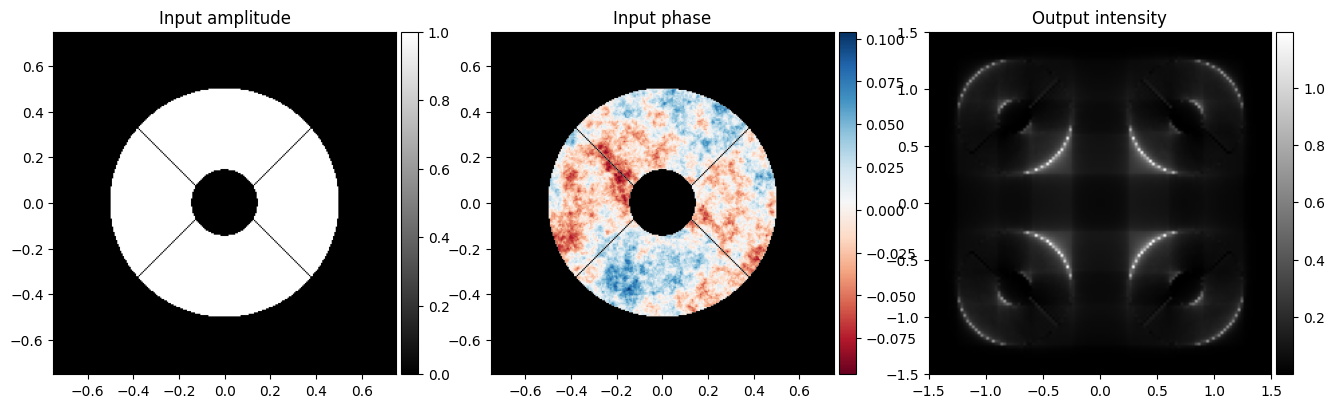

In [5]:
# Creating the aberrated wavefront
phase_aberrated = make_power_law_error(pupil_grid, 0.2, 1)
phase_aberrated -= np.mean(phase_aberrated[telescope_pupil >= 0.5])
wf = Wavefront(telescope_pupil * np.exp(1j * phase_aberrated), wavelength_wfs)

wf_out = pyr.forward(wf)
plot_pyr(wf, wf_out)

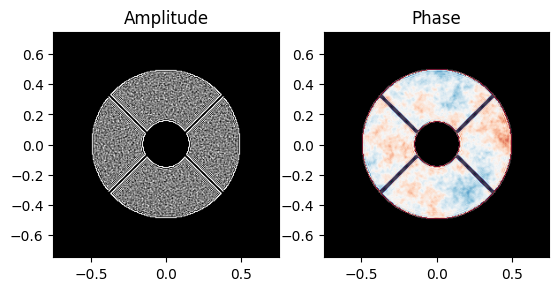

In [6]:
# Setting up the Fresnel propagator
prop_extra = FresnelPropagator(pupil_grid,distance=150)

# Creating the power law error
phase_aberrated = make_power_law_error(pupil_grid, ptv=0.3, diameter=telescope_diameter)
phase_aberrated -= np.mean(phase_aberrated[telescope_pupil >= 0.5])

# Removing the piston and tip-tilt modes.
zbasis = make_zernike_basis(3, 1, pupil_grid)
for test in zbasis:
    test*= telescope_pupil
    phase_aberrated -= test * np.dot(phase_aberrated, test) / np.dot(test, test)

# Use super-Gaussian to avoid edge effects
p = telescope_pupil * np.exp(-(pupil_grid.as_('polar').r / 0.68)**20)
# wf_new = prop_extra(Wavefront(np.exp(1j * phase_aberrated),wavelength=wavelength_wfs))
wf_new = prop_extra(Wavefront(p * np.exp(1j * phase_aberrated),wavelength=wavelength_wfs))
# wf_new = prop_extra(Wavefront(p * np.exp(1j * 2*np.pi/wavelength_wfs * phase_aberrated), wavelength=wavelength_wfs))

# Updating reference phase and multiplying with the telescope pupil
phase_aberrated = (wf_new.phase - np.pi) % (2 * np.pi) - np.pi
wf_new.electric_field[telescope_pupil < 0.5] = 0

# Plotting the aberration
plt.figure()
plt.subplot(1,2,1)
imshow_field((wf_new.amplitude * telescope_pupil)-1, cmap='gray', vmin=-0.02, vmax=0.02)
plt.title('Amplitude')
plt.subplot(1,2,2)
imshow_field(wf_new.phase*telescope_pupil, cmap='RdBu', mask=telescope_pupil, vmin=-0.2, vmax=0.2) #
plt.title('Phase')
plt.show()

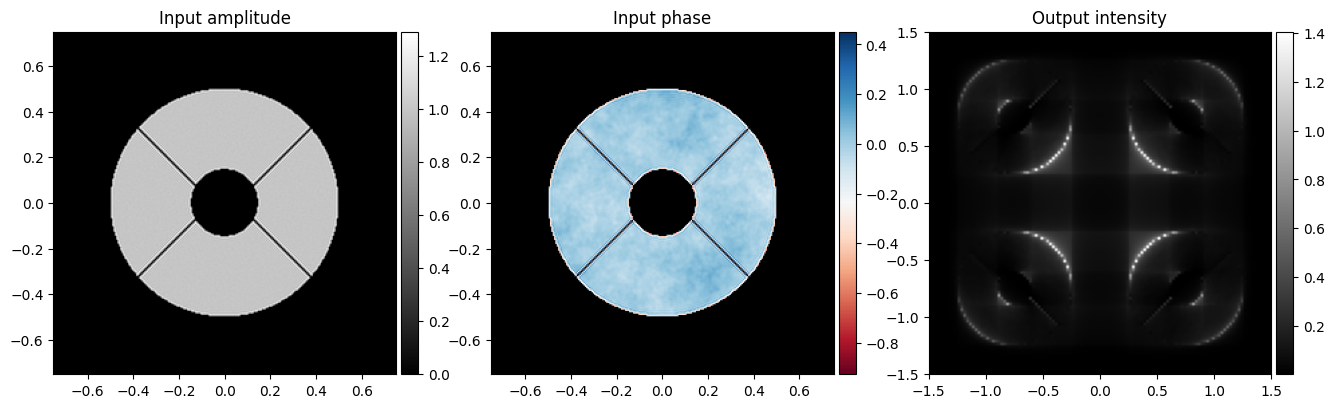

In [7]:
wf_out = pyr.forward(wf_new)
plot_pyr(wf_new, wf_out)

In [8]:
# Define 4 circular masks on the detector plane centered on pyramid WFS pupils
# The 4 pupils are positioned at (+/- separation/2, +/- separation/2)

separation = pupil_grid_diameter  # separation between pupils
pupil_radius = 1.0 / 2  # approximate radius of each pupil
obs_radius = 0.3 / 2  # approximate radius of each pupil

# Define the 4 center positions
pupil_centers = [
    (separation / 2, separation / 2),      # Top-right
    (-separation / 2, separation / 2),     # Top-left
    (-separation / 2, -separation / 2),    # Bottom-left
    (separation / 2, -separation / 2)      # Bottom-right
]

# Create 4 circular masks
masks = []
obs_masks = []
for center_x, center_y in pupil_centers:
    # Calculate distance from each point in pwfs_grid to the pupil center
    dx = pwfs_grid.x - center_x
    dy = pwfs_grid.y - center_y
    distance = np.sqrt(dx**2 + dy**2)
    
    # Create circular mask (1 inside, 0 outside)
    mask = (distance <= pupil_radius).astype(float)
    obs_mask = (distance <= obs_radius).astype(float)
    masks.append(Field(mask, pwfs_grid))
    obs_masks.append(Field(obs_mask, pwfs_grid))

for i,mask in enumerate(masks):
    mask -= obs_masks[i]
    mask = np.clip(mask, 0, 1)

# Optional: Create a combined mask with all 4 pupils
combined_mask = masks[0].copy()
for mask in masks[1:]:
    combined_mask += mask
combined_mask = np.clip(combined_mask, 0, 1)

# for mask in obs_masks:
#     combined_mask -= mask
# combined_mask = np.clip(combined_mask, 0, 1)

# # Plot the combined mask
# fig, ax = plt.subplots(figsize=(8, 8))
# im = imshow_field(combined_mask+wf_out.intensity, cmap='RdBu')
# plt.title('Combined Mask (All 4 Pupils)')
# divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='5%', pad=0.05)
# fig.colorbar(im, cax=cax, orientation='vertical')
# plt.show()

# # Plot the combined mask
# fig, ax = plt.subplots(figsize=(8, 8))
# im = imshow_field(combined_mask, cmap='gray')
# plt.title('Combined Mask (All 4 Pupils)')
# divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='5%', pad=0.05)
# fig.colorbar(im, cax=cax, orientation='vertical')
# plt.show()


In [9]:
wf = prop_extra(Wavefront(p * np.exp(1j * phase_aberrated*0),wavelength=wavelength_wfs))
wf_ref = pyr.forward(wf)

In [19]:
def get_signal(wf):
    frame = wf.intensity.copy()
    signal = frame[masks[0].astype(bool)]
    for i in range(3):
        signal += frame[masks[i+1].astype(bool)]
    return signal

def plot_signal(signal):
    image = masks[0].copy()
    image[masks[0].astype(bool)] = signal
    plt.figure()
    imshow_field(image,cmap='turbo',mask=masks[0])
    plt.colorbar()

In [20]:
ref_signal = get_signal(wf_ref)
signal = get_signal(wf_out)


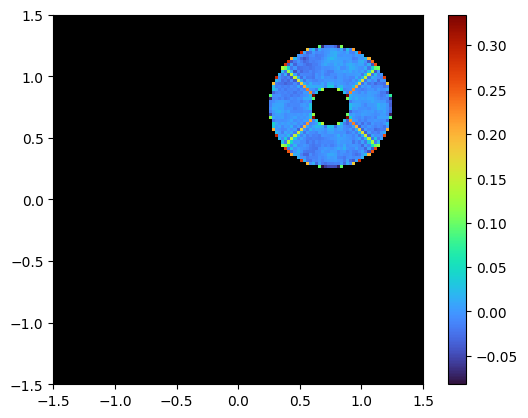

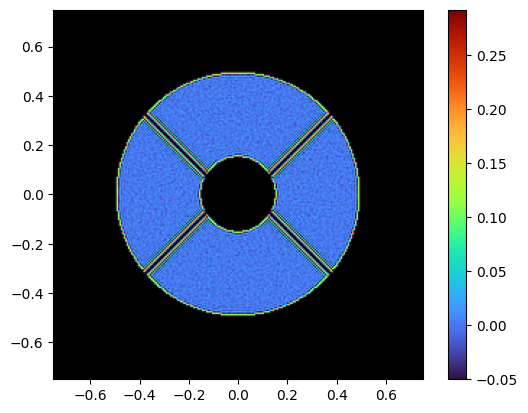

In [23]:

# plot_signal(signal)
# plot_signal(ref_signal)
plot_signal(signal-ref_signal)

plt.figure()
imshow_field(wf_new.amplitude-1,cmap='turbo',mask=telescope_pupil,vmin=-0.05)
plt.colorbar()
